# PES example

This makes a 2D energy plot from a relaxed structure, an attacked structure, and the final relaxed structure. It uses a example energy equation so it runs anywhere.

Create the three structures. Each row is one atom: `[x, y, z]` in Å.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

# relaxation->perturbation->relaxation
# on HPC this would normally be imported from .traj/.cif/.csv files
# that were already generated
ref = np.array([[0., 0., 0.], [1.5, 0., 0.]])
attack = np.array([[.3, 0., 0.], [1.5, 0., 0.]])
final = np.array([[.65, .2, 0.], [1.5, -.2, 0.]])

Find the two directions for the x and y-axis. The first direction is the attack; the second is the part of relaxation that points away from the attack.

In [3]:
u1 = (attack - ref).ravel(); u1 /= np.linalg.norm(u1)
u2 = (final - ref).ravel(); u2 -= u2.dot(u1) * u1; u2 /= np.linalg.norm(u2)

# Put a structure onto the 2D plot.
point = lambda s: [(s - ref).ravel().dot(u1), (s - ref).ravel().dot(u2)]
start, hit, end = map(point, [ref, attack, final])

Make an example energy map. A real MLFF would calculate these energies; this short equation just makes a low-energy area near the final structure.

In [4]:
x = np.linspace(-.1, .8, 100); y = np.linspace(-.5, .5, 100)
X, Y = np.meshgrid(x, y)
E = 50 * (X * (X - end[0]))**2 + 3 * Y**2 - .5 * X / end[0]

Plot an energy map. The dashed line is the attack and the solid line is relaxation toward the final structure.

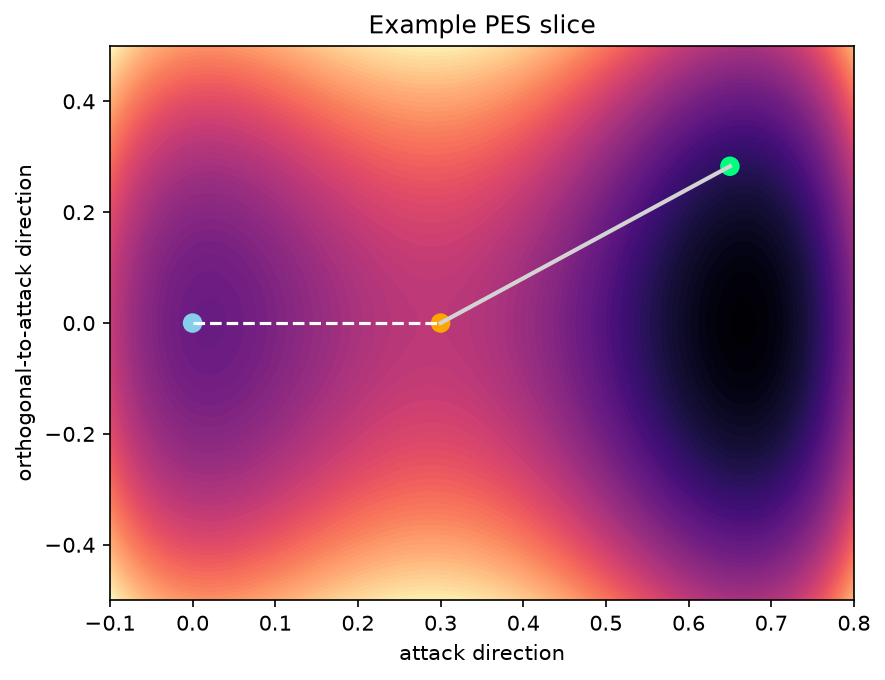

In [5]:
# Blue = relaxation
# Orange = perturbation
# Green = recovery
fig, ax = plt.subplots()
ax.contourf(X, Y, E, 80, cmap='magma')
ax.plot([start[0], hit[0]], [start[1], hit[1]], '--w')
ax.plot([hit[0], end[0]], [hit[1], end[1]], color='lightgray', lw=2)
ax.scatter(*zip(start, hit, end), c=['skyblue', 'orange', 'springgreen'], s=70)
ax.set(xlabel='attack direction', ylabel='orthogonal-to-attack direction', title='Example PES slice')
fig.savefig('example_pes.png', dpi=150, bbox_inches='tight')
display(Image(filename='example_pes.png'))
plt.close(fig)